# Fase 1 – Modelo predictivo: ¿el pasajero dejará una propina generosa?

**Proyecto Integrado – Modelos y Simulación de Sistemas I – Universidad de Antioquia**

- Oscar Julian Toro Arroyave – o.toro@udea.edu.co
- Esteban Barrera Sanabria – esteban.barreras@udea.edu.co

**Problema:** clasificación binaria. A partir de las características de un viaje en taxi amarillo de Nueva York se predice si la propina será **igual o mayor al 20 % de la tarifa** (`propina_generosa = 1`) o menor (`propina_generosa = 0`).

**Datos:** *NYC Yellow Taxi Trip Data* (Kaggle, a partir de los registros de la NYC TLC), archivo `yellow_tripdata_2015-01.csv` (12,7 millones de viajes).

**Contenido del notebook**

1. Configuración y carga de datos
2. Exploración inicial
3. Variable objetivo
4. Calidad de los datos
5. Análisis exploratorio
6. Limpieza
7. Ingeniería de variables
8. Selección de variables y control de fuga de información
9. División entrenamiento / prueba
10. Preprocesamiento y modelos
11. Ajuste de hiperparámetros
12. Evaluación final en el conjunto de prueba
13. Importancia de variables
14. Guardado del modelo
15. Conclusiones

> **Cómo ejecutarlo:** en Google Colab, *Entorno de ejecución → Ejecutar todas*. El notebook descarga el archivo de Kaggle por sí mismo; no hace falta subir nada. Tarda entre 10 y 15 minutos.
>
> Si la descarga automática falla, descargue `yellow_tripdata_2015-01.csv` desde la página del dataset en Kaggle, súbalo a Colab (ícono de carpeta a la izquierda) y ponga `RUTA_CSV = "/content/yellow_tripdata_2015-01.csv"` en la sección 1.

In [1]:
# Librerías
import os, json, time, platform
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sklearn

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, classification_report)
from sklearn.inspection import permutation_importance

SEMILLA = 42
np.random.seed(SEMILLA)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (9, 4)

print("pandas", pd.__version__, "| scikit-learn", sklearn.__version__, "| Python", platform.python_version())

pandas 2.2.3 | scikit-learn 1.6.1 | Python 3.13.15


## 1. Configuración y carga de datos

El archivo de enero de 2015 pesa cerca de 2 GB y tiene 12,7 millones de filas, así que **no se carga completo en memoria**. Se lee por bloques de un millón de filas y en cada bloque:

1. Se conservan solo los viajes **pagados con tarjeta** (`payment_type == 1`) y con **tarifa mayor a cero**. En los registros de la TLC las propinas en efectivo no quedan registradas (aparecen en 0), así que incluir esos viajes haría que el modelo aprendiera el método de pago y no el comportamiento de propina.
2. Se toma una **muestra aleatoria del 5 %** con semilla fija, para que el resultado sea reproducible.

Con esto quedan alrededor de 390.000 viajes, muy por encima del mínimo de 1.000 observaciones y suficientes para entrenar sin agotar la memoria de Colab.

Si ya tiene el CSV descargado, ponga su ruta en `RUTA_CSV` y el notebook no descargará nada.

In [2]:
RUTA_CSV = None                      # ej: "data/yellow_tripdata_2015-01.csv"; None = descargar de Kaggle
ARCHIVO = "yellow_tripdata_2015-01.csv"
DATASET_KAGGLE = "elemento/nyc-yellow-taxi-trip-data"
FRACCION_MUESTRA = 0.05
TAMANO_BLOQUE = 1_000_000
UMBRAL_PROPINA = 0.20

if RUTA_CSV is None:
    import kagglehub  # viene instalado en Colab; si no: pip install kagglehub
    RUTA_CSV = kagglehub.dataset_download(DATASET_KAGGLE, path=ARCHIVO)

print("Archivo:", RUTA_CSV)

100%|██████████| 504M/504M [00:22<00:00, 23.0MB/s]

Extracting zip of yellow_tripdata_2015-01.csv...


Archivo: /root/.cache/kagglehub/datasets/elemento/nyc-yellow-taxi-trip-data/versions/2/yellow_tripdata_2015-01.csv


In [3]:
inicio = time.time()
total_filas, filas_filtradas = 0, 0
nulos_originales = None
conteo_pagos = None
partes = []

for bloque in pd.read_csv(RUTA_CSV, chunksize=TAMANO_BLOQUE, low_memory=False):
    # En 2015 la columna se llama RateCodeID y en 2016 RatecodeID: se normaliza a minúsculas
    bloque.columns = bloque.columns.str.strip().str.lower()
    total_filas += len(bloque)

    n = bloque.isna().sum()
    nulos_originales = n if nulos_originales is None else nulos_originales + n
    c = bloque["payment_type"].value_counts()
    conteo_pagos = c if conteo_pagos is None else conteo_pagos.add(c, fill_value=0)

    bloque = bloque[(bloque["payment_type"] == 1) & (bloque["fare_amount"] > 0)]
    filas_filtradas += len(bloque)
    partes.append(bloque.sample(frac=FRACCION_MUESTRA, random_state=SEMILLA))

df_raw = pd.concat(partes, ignore_index=True)
del partes

print(f"Filas en el archivo original:            {total_filas:,}")
print(f"Filas pagadas con tarjeta y tarifa > 0:  {filas_filtradas:,}")
print(f"Filas en la muestra de trabajo:          {len(df_raw):,}")
print(f"Tiempo de carga: {time.time() - inicio:,.0f} s")

Filas en el archivo original:            12,748,986
Filas pagadas con tarjeta y tarifa > 0:  7,880,666
Filas en la muestra de trabajo:          394,034
Tiempo de carga: 64 s


In [4]:
# Métodos de pago en el archivo completo (1 = tarjeta, 2 = efectivo, 3 = sin cargo, 4 = disputa)
(conteo_pagos / total_filas * 100).rename("% de viajes").to_frame()

,% de viajes
payment_type,
1,61.8197
2,37.7833
3,0.3030
4,0.0939
5,0.0000


## 2. Exploración inicial

In [5]:
print("Dimensiones de la muestra:", df_raw.shape)
df_raw.head()

Dimensiones de la muestra: (394034, 19)


,vendorid,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,ratecodeid,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2015-01-05 16:26:58,2015-01-05 16:32:55,1,0.7200,-73.9829,40.7710,1,N,-73.9893,40.7744,1,6.0000,1.0000,0.5000,1.5000,0.0000,0.3000,9.3000
1,2,2015-01-06 07:10:24,2015-01-06 07:36:54,4,10.0100,-73.9536,40.8224,1,N,-74.0076,40.7046,1,30.5000,0.0000,0.5000,3.0000,0.0000,0.3000,34.3000
2,2,2015-01-12 12:28:59,2015-01-12 12:38:59,1,2.4000,-73.9814,40.7808,1,N,-73.9648,40.8102,1,10.5000,0.0000,0.5000,2.1000,0.0000,0.3000,13.4000
3,2,2015-01-03 19:32:45,2015-01-03 19:42:20,5,1.5800,-73.9814,40.7291,1,N,-74.0043,40.7285,1,8.5000,0.0000,0.5000,1.7000,0.0000,0.3000,11.0000
4,1,2015-01-12 09:01:01,2015-01-12 09:26:41,1,3.5000,-73.9816,40.7408,1,N,-73.9820,40.7797,1,18.0000,0.0000,0.5000,3.7500,0.0000,0.3000,22.5500


In [6]:
df_raw.dtypes.rename("tipo").to_frame()

,tipo
vendorid,int64
tpep_pickup_datetime,object
tpep_dropoff_datetime,object
passenger_count,int64
trip_distance,float64
pickup_longitude,float64
pickup_latitude,float64
ratecodeid,int64
store_and_fwd_flag,object
dropoff_longitude,float64


In [7]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
vendorid,"394,034.0000",1.5239,0.4994,1.0000,1.0000,2.0000,2.0000,2.0000
passenger_count,"394,034.0000",1.6665,1.3353,0.0000,1.0000,1.0000,2.0000,8.0000
trip_distance,"394,034.0000",12.1500,"5,307.3422",0.0000,1.0900,1.8000,3.2300,"3,318,000.0000"
pickup_longitude,"394,034.0000",-72.5800,10.0633,-74.6582,-73.9923,-73.9821,-73.9678,0.0000
pickup_latitude,"394,034.0000",39.9814,5.5436,0.0000,40.7341,40.7516,40.7668,44.9586
ratecodeid,"394,034.0000",1.0401,0.5722,1.0000,1.0000,1.0000,1.0000,99.0000
dropoff_longitude,"394,034.0000",-72.7069,9.6031,-74.6658,-73.9918,-73.9804,-73.9635,0.0000
dropoff_latitude,"394,034.0000",40.0519,5.2901,0.0000,40.7328,40.7519,40.7682,48.3937
payment_type,"394,034.0000",1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
fare_amount,"394,034.0000",12.5123,10.6720,0.0100,6.5000,9.5000,14.0000,845.0300


In [8]:
# Valores nulos clásicos (NaN) en el archivo completo
nulos_originales.rename("NaN en archivo completo").to_frame()

,NaN en archivo completo
vendorid,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
pickup_longitude,0
pickup_latitude,0
ratecodeid,0
store_and_fwd_flag,0
dropoff_longitude,0


## 3. Variable objetivo

`propina_generosa = 1` si `tip_amount / fare_amount >= 0.20`, y `0` en caso contrario.

propina_generosa
0   31.0700
1   68.9300
Name: % de viajes, dtype: float64


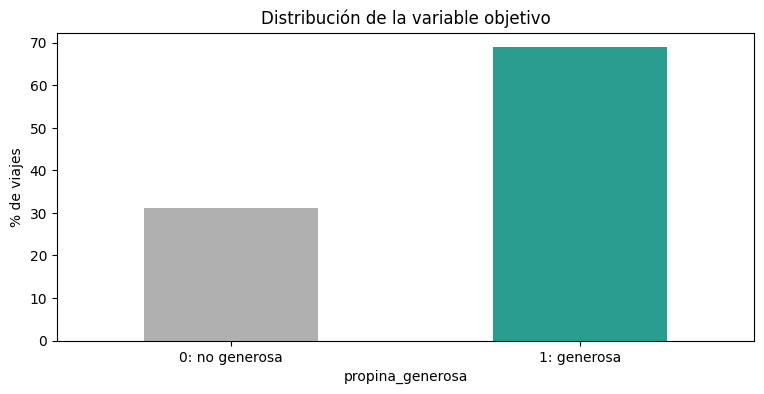

In [9]:
df = df_raw.copy()
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])
df["tasa_propina"] = df["tip_amount"] / df["fare_amount"]
df["propina_generosa"] = (df["tasa_propina"] >= UMBRAL_PROPINA).astype(int)

dist_obj = df["propina_generosa"].value_counts(normalize=True).sort_index() * 100
print(dist_obj.round(2).rename("% de viajes"))

ax = dist_obj.plot(kind="bar", color=["#b0b0b0", "#2a9d8f"])
ax.set_xticklabels(["0: no generosa", "1: generosa"], rotation=0)
ax.set_ylabel("% de viajes"); ax.set_title("Distribución de la variable objetivo")
plt.show()

La clase mayoritaria es la propina generosa (alrededor de dos tercios de los viajes). Las clases no están muy desbalanceadas, pero sí lo suficiente como para que la **exactitud (accuracy) por sí sola sea engañosa**: un modelo que siempre dijera "generosa" ya acertaría en la mayoría de casos. Por eso se usa un modelo base de referencia y métricas que no dependen del balance, como ROC-AUC y exactitud balanceada.

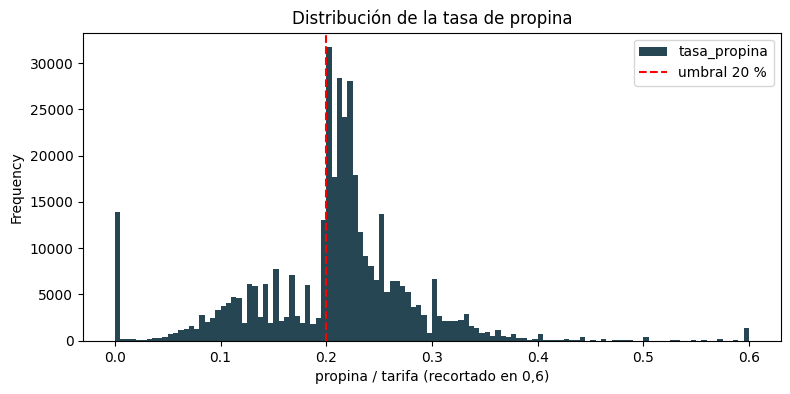

In [10]:
# Distribución de la tasa de propina (propina / tarifa)
ax = df["tasa_propina"].clip(upper=0.6).plot(kind="hist", bins=120, color="#264653")
ax.axvline(UMBRAL_PROPINA, color="red", linestyle="--", label="umbral 20 %")
ax.set_xlabel("propina / tarifa (recortado en 0,6)"); ax.set_title("Distribución de la tasa de propina")
ax.legend(); plt.show()

La tasa de propina **no es continua y suave**: aparecen picos muy marcados. Esto se explica porque en los taxis de Nueva York el pasajero paga con tarjeta en una pantalla que ofrece botones de propina sugerida (porcentajes fijos). Como esos porcentajes se calculan sobre un monto que incluye recargos, la propina resultante suele quedar algo por encima del porcentaje sobre la tarifa base. Esto hace que el umbral del 20 % sea una forma natural de separar a quienes usan los botones sugeridos de quienes escriben un valor menor o no dejan propina.

## 4. Calidad de los datos

Se revisan valores que, aunque no sean NaN, en la práctica son datos faltantes o imposibles.

In [11]:
duracion = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60

# Caja geográfica amplia alrededor de Nueva York (incluye los aeropuertos JFK, LaGuardia y Newark)
LAT_MIN, LAT_MAX, LON_MIN, LON_MAX = 40.45, 41.00, -74.30, -73.65
fuera_rec = ~(df["pickup_latitude"].between(LAT_MIN, LAT_MAX) & df["pickup_longitude"].between(LON_MIN, LON_MAX))
fuera_des = ~(df["dropoff_latitude"].between(LAT_MIN, LAT_MAX) & df["dropoff_longitude"].between(LON_MIN, LON_MAX))

calidad = pd.Series({
    "Recogida en (0, 0)": ((df["pickup_latitude"] == 0) | (df["pickup_longitude"] == 0)).mean(),
    "Destino en (0, 0)": ((df["dropoff_latitude"] == 0) | (df["dropoff_longitude"] == 0)).mean(),
    "Recogida fuera de NYC (incluye 0,0)": fuera_rec.mean(),
    "Destino fuera de NYC (incluye 0,0)": fuera_des.mean(),
    "Distancia <= 0": (df["trip_distance"] <= 0).mean(),
    "Distancia >= 100 millas": (df["trip_distance"] >= 100).mean(),
    "Duración < 1 min": (duracion < 1).mean(),
    "Duración > 3 horas": (duracion > 180).mean(),
    "Pasajeros fuera de 1 a 6": (~df["passenger_count"].between(1, 6)).mean(),
    "Propina negativa": (df["tip_amount"] < 0).mean(),
    "RateCodeID fuera de 1 a 6": (~df["ratecodeid"].between(1, 6)).mean(),
    "Tarifa >= 500 USD": (df["fare_amount"] >= 500).mean(),
}) * 100
calidad.round(3).rename("% de la muestra").to_frame()

,% de la muestra
"Recogida en (0, 0)",1.8860
"Destino en (0, 0)",1.7150
"Recogida fuera de NYC (incluye 0,0)",1.8990
"Destino fuera de NYC (incluye 0,0)",1.7530
Distancia <= 0,0.3460
Distancia >= 100 millas,0.0020
Duración < 1 min,0.4310
Duración > 3 horas,0.0660
Pasajeros fuera de 1 a 6,0.0520
Propina negativa,0.0000


**Decisiones sobre calidad:**

- **Coordenadas en (0, 0) o fuera de Nueva York.** En esos viajes la distancia y la tarifa sí son válidas, así que no se eliminan: las coordenadas se convierten en **valores faltantes (NaN)** y se agrega una variable indicadora `coords_faltantes`. Después, la imputación se hace **dentro del pipeline** con la mediana calculada solo sobre el conjunto de entrenamiento (sección 10), para no filtrar información del conjunto de prueba.
- **Distancias, duraciones, pasajeros, tarifas y códigos imposibles.** Son registros erróneos (viajes de duración negativa, 0 pasajeros, códigos de tarifa inexistentes) y representan una fracción pequeña, así que se eliminan.

## 5. Análisis exploratorio

Se compara la tasa de propina generosa según distintas características del viaje. Las líneas punteadas marcan la tasa promedio.

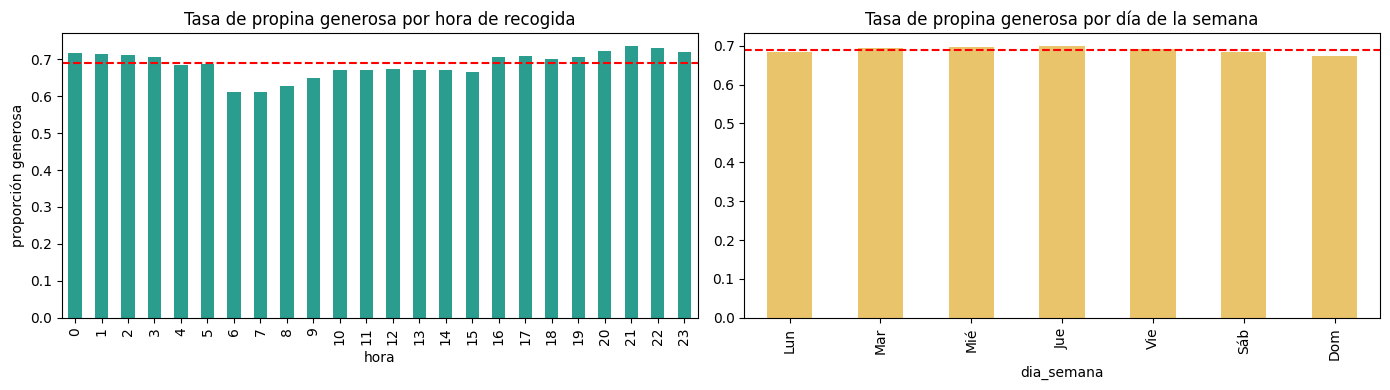

In [12]:
df["hora"] = df["tpep_pickup_datetime"].dt.hour
df["dia_semana"] = df["tpep_pickup_datetime"].dt.dayofweek
media = df["propina_generosa"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df.groupby("hora")["propina_generosa"].mean().plot(kind="bar", ax=axes[0], color="#2a9d8f")
axes[0].axhline(media, color="red", linestyle="--"); axes[0].set_title("Tasa de propina generosa por hora de recogida")
axes[0].set_ylabel("proporción generosa")
dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
df.groupby("dia_semana")["propina_generosa"].mean().rename(index=dict(enumerate(dias))).plot(kind="bar", ax=axes[1], color="#e9c46a")
axes[1].axhline(media, color="red", linestyle="--"); axes[1].set_title("Tasa de propina generosa por día de la semana")
plt.tight_layout(); plt.show()

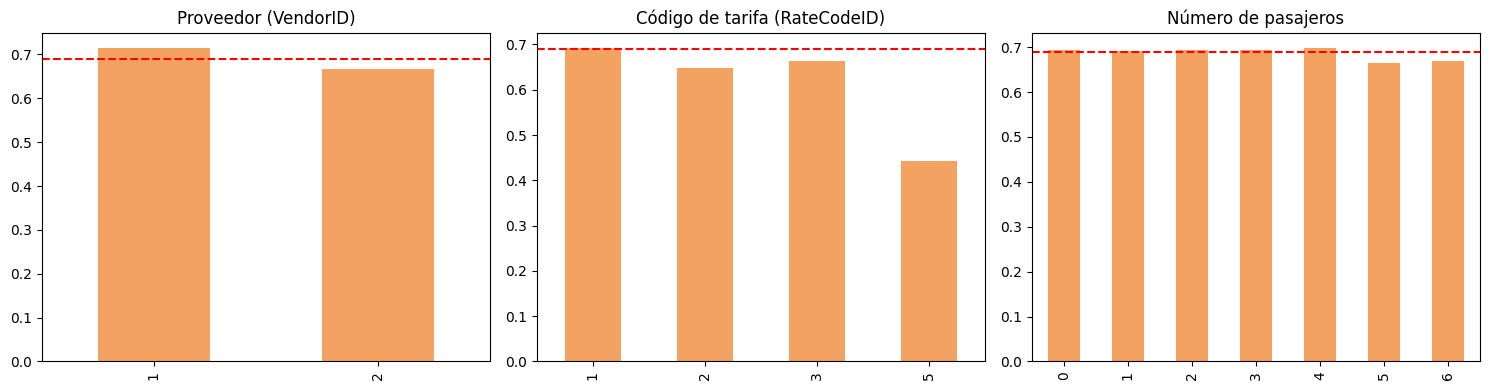

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, titulo in zip(axes, ["vendorid", "ratecodeid", "passenger_count"],
                           ["Proveedor (VendorID)", "Código de tarifa (RateCodeID)", "Número de pasajeros"]):
    tabla = df.groupby(col)["propina_generosa"].agg(["mean", "size"])
    tabla = tabla[tabla["size"] >= 100]  # solo categorías con suficientes viajes
    tabla["mean"].plot(kind="bar", ax=ax, color="#f4a261")
    ax.axhline(media, color="red", linestyle="--"); ax.set_title(titulo); ax.set_xlabel("")
plt.tight_layout(); plt.show()

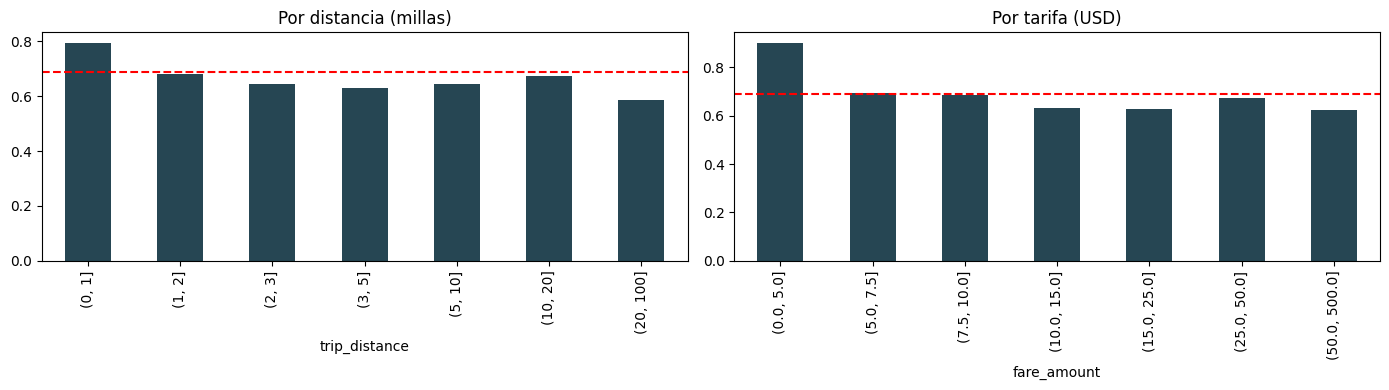

In [14]:
# Tasa de propina generosa según rangos de distancia y de tarifa
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
rangos_dist = pd.cut(df["trip_distance"], [0, 1, 2, 3, 5, 10, 20, 100])
df.groupby(rangos_dist, observed=True)["propina_generosa"].mean().plot(kind="bar", ax=axes[0], color="#264653")
axes[0].axhline(media, color="red", linestyle="--"); axes[0].set_title("Por distancia (millas)")
rangos_tarifa = pd.cut(df["fare_amount"], [0, 5, 7.5, 10, 15, 25, 50, 500])
df.groupby(rangos_tarifa, observed=True)["propina_generosa"].mean().plot(kind="bar", ax=axes[1], color="#264653")
axes[1].axhline(media, color="red", linestyle="--"); axes[1].set_title("Por tarifa (USD)")
plt.tight_layout(); plt.show()

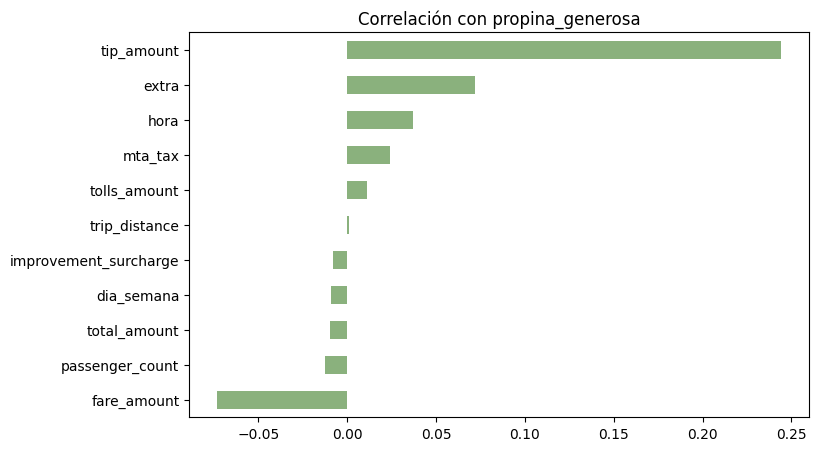

In [15]:
# Correlación de las variables numéricas con la variable objetivo (solo como guía; es lineal)
cols_corr = ["trip_distance", "fare_amount", "extra", "tolls_amount", "passenger_count", "hora",
             "dia_semana", "mta_tax", "improvement_surcharge", "tip_amount", "total_amount"]
corr = df[cols_corr + ["propina_generosa"]].corr(numeric_only=True)["propina_generosa"].drop("propina_generosa")
corr.sort_values().plot(kind="barh", color="#8ab17d", figsize=(8, 5))
plt.title("Correlación con propina_generosa"); plt.show()

**Lectura de las gráficas:**

- `tip_amount` y `total_amount` aparecen entre las más correlacionadas con el objetivo. No es casualidad: **contienen la propina**, que es justamente lo que se quiere predecir. Por eso se excluyen (sección 8).
- El proveedor, el código de tarifa, la hora y la tarifa muestran diferencias en la tasa de propina generosa, así que se conservan como predictoras.
- Las relaciones no son lineales (por ejemplo, la tasa no sube o baja de forma constante con la distancia), lo que justifica probar un modelo basado en árboles además del modelo lineal.

## 6. Limpieza

In [16]:
def limpiar(datos):
    d = datos.copy()
    d["duracion_min"] = (d["tpep_dropoff_datetime"] - d["tpep_pickup_datetime"]).dt.total_seconds() / 60
    reglas = {
        "distancia entre 0 y 100 millas": (d["trip_distance"] > 0) & (d["trip_distance"] < 100),
        "duración entre 1 y 180 min": d["duracion_min"].between(1, 180),
        "pasajeros entre 1 y 6": d["passenger_count"].between(1, 6),
        "propina no negativa": d["tip_amount"] >= 0,
        "tarifa menor a 500 USD": d["fare_amount"] < 500,
        "RateCodeID entre 1 y 6": d["ratecodeid"].between(1, 6),
    }
    mascara = pd.Series(True, index=d.index)
    for nombre, regla in reglas.items():
        eliminadas = (mascara & ~regla).sum()
        print(f"  {nombre:<35} elimina {eliminadas:>7,} filas")
        mascara &= regla
    d = d[mascara].copy()

    # Velocidad promedio: se descartan velocidades imposibles para un taxi en la ciudad
    d["velocidad_mph"] = d["trip_distance"] / (d["duracion_min"] / 60)
    antes = len(d)
    d = d[d["velocidad_mph"] < 80].copy()
    print(f"  {'velocidad menor a 80 mph':<35} elimina {antes - len(d):>7,} filas")

    # Coordenadas en (0,0) o fuera de NYC -> NaN (se imputan después, dentro del pipeline)
    for p in ["pickup", "dropoff"]:
        fuera = ~(d[f"{p}_latitude"].between(LAT_MIN, LAT_MAX) & d[f"{p}_longitude"].between(LON_MIN, LON_MAX))
        d.loc[fuera, [f"{p}_latitude", f"{p}_longitude"]] = np.nan
    return d

print("Filas antes de limpiar:", f"{len(df):,}")
df_limpio = limpiar(df)
print("Filas después de limpiar:", f"{len(df_limpio):,}", f"({len(df_limpio) / len(df) * 100:.2f} % conservado)")

Filas antes de limpiar: 394,034
  distancia entre 0 y 100 millas      elimina   1,372 filas
  duración entre 1 y 180 min          elimina     829 filas
  pasajeros entre 1 y 6               elimina     195 filas
  propina no negativa                 elimina       0 filas
  tarifa menor a 500 USD              elimina       0 filas
  RateCodeID entre 1 y 6              elimina       6 filas
  velocidad menor a 80 mph            elimina      17 filas
Filas después de limpiar: 391,615 (99.39 % conservado)


In [17]:
# Duplicados exactos
print("Filas duplicadas:", df_limpio.duplicated().sum())
df_limpio = df_limpio.drop_duplicates()

Filas duplicadas: 0


## 7. Ingeniería de variables

A partir de las columnas originales se construyen variables más útiles para el modelo:

| Variable | Cómo se calcula | Por qué |
|---|---|---|
| `duracion_min` | llegada − recogida | viajes largos o con tráfico pueden cambiar la propina |
| `velocidad_mph` | distancia / duración | resume el tráfico del viaje |
| `tarifa_por_milla` | tarifa / distancia | detecta tarifas fijas (aeropuerto) o viajes muy cortos |
| `hora_sin`, `hora_cos` | seno y coseno de la hora | la hora es cíclica: las 23 h están cerca de las 0 h |
| `dia_semana`, `fin_de_semana` | día de la recogida | comportamiento distinto entre semana y fin de semana |
| `dist_centro_recogida`, `dist_centro_destino` | distancia en km a Midtown Manhattan | aproxima la zona del viaje |
| `aeropuerto` | recogida o destino a menos de 2 km de JFK, LaGuardia o Newark | viajes de aeropuerto tienen tarifa y perfil distintos |
| `coords_faltantes` | 1 si alguna coordenada era inválida | conserva la información de que el dato faltaba |

In [18]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

MIDTOWN = (40.7580, -73.9855)
AEROPUERTOS = {"JFK": (40.6413, -73.7781), "LGA": (40.7769, -73.8740), "EWR": (40.6895, -74.1745)}

def crear_variables(d):
    d = d.copy()
    hora = d["tpep_pickup_datetime"].dt.hour
    d["hora"] = hora
    d["hora_sin"] = np.sin(2 * np.pi * hora / 24)
    d["hora_cos"] = np.cos(2 * np.pi * hora / 24)
    d["dia_semana"] = d["tpep_pickup_datetime"].dt.dayofweek
    d["fin_de_semana"] = (d["dia_semana"] >= 5).astype(int)
    d["tarifa_por_milla"] = d["fare_amount"] / d["trip_distance"]
    d["dist_centro_recogida"] = haversine_km(d["pickup_latitude"], d["pickup_longitude"], *MIDTOWN)
    d["dist_centro_destino"] = haversine_km(d["dropoff_latitude"], d["dropoff_longitude"], *MIDTOWN)
    cerca = pd.Series(False, index=d.index)
    for lat, lon in AEROPUERTOS.values():
        cerca |= haversine_km(d["pickup_latitude"], d["pickup_longitude"], lat, lon) < 2
        cerca |= haversine_km(d["dropoff_latitude"], d["dropoff_longitude"], lat, lon) < 2
    d["aeropuerto"] = (cerca | d["ratecodeid"].isin([2, 3])).astype(int)
    d["coords_faltantes"] = d[["pickup_latitude", "pickup_longitude",
                               "dropoff_latitude", "dropoff_longitude"]].isna().any(axis=1).astype(int)
    return d

df_modelo = crear_variables(df_limpio)
df_modelo[["duracion_min", "velocidad_mph", "tarifa_por_milla", "dist_centro_recogida",
           "dist_centro_destino", "aeropuerto", "coords_faltantes"]].describe().T

,count,mean,std,min,25%,50%,75%,max
duracion_min,"391,615.0000",12.9012,9.2258,1.0000,6.6167,10.5667,16.5000,178.7667
velocidad_mph,"391,615.0000",12.7173,6.3891,0.0098,8.5409,11.2662,15.0258,76.8750
tarifa_por_milla,"391,615.0000",5.5273,11.1942,0.0003,4.0541,5.0000,6.3636,"5,200.0000"
dist_centro_recogida,"384,709.0000",3.0593,3.1250,0.0017,1.2963,2.3754,3.6597,28.9934
dist_centro_destino,"385,274.0000",3.3242,3.0487,0.0017,1.3974,2.5973,4.0325,37.9764
aeropuerto,"391,615.0000",0.0616,0.2404,0.0000,0.0000,0.0000,0.0000,1.0000
coords_faltantes,"391,615.0000",0.0182,0.1337,0.0000,0.0000,0.0000,0.0000,1.0000


## 8. Selección de variables y control de fuga de información

La **fuga de información** ocurre cuando el modelo recibe datos que no estarían disponibles en el momento de hacer la predicción, o que contienen la respuesta. Un modelo con fuga obtiene métricas excelentes en el notebook y falla en la práctica.

El momento de predicción es **el final del viaje, justo antes de que el pasajero elija la propina**. En ese momento ya se conocen la distancia, la duración, la tarifa, los recargos y los peajes, pero **no** la propina.

**Variables excluidas:**

| Variable | Motivo |
|---|---|
| `tip_amount` | Es la propina: con ella se construye la variable objetivo. **Fuga directa.** |
| `total_amount` | Incluye la propina. **Fuga directa.** |
| `tasa_propina` | Variable auxiliar creada a partir de la propina. **Fuga directa.** |
| `payment_type` | Después del filtro solo queda el valor 1 (tarjeta); ya no aporta información. |
| `mta_tax`, `improvement_surcharge` | Casi constantes (ver celda siguiente); no aportan información. |
| `store_and_fwd_flag` | Casi constante y describe cómo se transmitió el registro, no el viaje. |
| `tpep_pickup_datetime`, `tpep_dropoff_datetime` | Se reemplazan por las variables derivadas (hora, día, duración). |

**Corrección respecto al informe inicial:** `fare_amount` **se conserva**. La tarifa se conoce antes de que el pasajero decida la propina (aparece en la pantalla del taxi), así que no contiene la respuesta. Que la tarifa sea el denominador de la tasa de propina no la convierte en fuga: el modelo recibe la tarifa, pero nunca la propina.

In [19]:
for col in ["mta_tax", "improvement_surcharge", "store_and_fwd_flag"]:
    frec = df_modelo[col].value_counts(normalize=True, dropna=False).head(3) * 100
    print(f"{col}: " + ", ".join(f"{k} = {v:.2f} %" for k, v in frec.items()))

mta_tax: 0.5 = 99.75 %, 0.0 = 0.25 %
improvement_surcharge: 0.3 = 95.29 %, 0.0 = 4.71 %
store_and_fwd_flag: N = 99.18 %, Y = 0.82 %


In [20]:
VARIABLES_NUMERICAS = [
    "fare_amount", "trip_distance", "duracion_min", "velocidad_mph", "tarifa_por_milla",
    "extra", "tolls_amount", "passenger_count",
    "hora_sin", "hora_cos", "dia_semana", "fin_de_semana",
    "pickup_latitude", "pickup_longitude", "dropoff_latitude", "dropoff_longitude",
    "dist_centro_recogida", "dist_centro_destino", "aeropuerto", "coords_faltantes",
]
VARIABLES_CATEGORICAS = ["vendorid", "ratecodeid"]
OBJETIVO = "propina_generosa"
PROHIBIDAS = ["tip_amount", "total_amount", "tasa_propina", "payment_type"]

VARIABLES = VARIABLES_NUMERICAS + VARIABLES_CATEGORICAS
assert not set(VARIABLES) & set(PROHIBIDAS), "Hay una variable con fuga de información entre las predictoras"

X = df_modelo[VARIABLES].copy()
X[VARIABLES_CATEGORICAS] = X[VARIABLES_CATEGORICAS].astype(int).astype(str)
y = df_modelo[OBJETIVO].copy()
print("X:", X.shape, "| y:", y.shape)
print("Valores faltantes por variable (antes de imputar):")
print(X.isna().sum()[X.isna().sum() > 0])

X: (391615, 22) | y: (391615,)
Valores faltantes por variable (antes de imputar):
pickup_latitude         6906
pickup_longitude        6906
dropoff_latitude        6341
dropoff_longitude       6341
dist_centro_recogida    6906
dist_centro_destino     6341
dtype: int64


## 9. División entrenamiento / prueba

Se separa **antes de cualquier ajuste** (imputación, escalado, entrenamiento o búsqueda de hiperparámetros):

- 80 % entrenamiento, 20 % prueba.
- División **estratificada**, para mantener la misma proporción de clases en ambos conjuntos.
- El conjunto de prueba **se usa una sola vez**, al final (sección 12). Toda la comparación de modelos y el ajuste de hiperparámetros se hacen con validación cruzada dentro del entrenamiento.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEMILLA
)
print(f"Entrenamiento: {len(X_train):,} filas | Prueba: {len(X_test):,} filas")
print("Proporción de clase 1 -> entrenamiento: %.4f | prueba: %.4f" % (y_train.mean(), y_test.mean()))

Entrenamiento: 313,292 filas | Prueba: 78,323 filas
Proporción de clase 1 -> entrenamiento: 0.6899 | prueba: 0.6899


## 10. Preprocesamiento y modelos

Todo el preprocesamiento va **dentro de un `Pipeline` de scikit-learn**. Así, en cada partición de la validación cruzada la mediana para imputar, la media y desviación para escalar y las categorías del one-hot se calculan **solo con los datos de entrenamiento de esa partición**, sin mirar los datos de validación ni de prueba. Esto evita la fuga de información por preprocesamiento.

Modelos comparados:

1. **Modelo base (`DummyClassifier`)**: siempre predice la clase más frecuente. Sirve como piso: cualquier modelo útil debe superarlo.
2. **Regresión logística**: modelo lineal, rápido e interpretable.
3. **Gradient Boosting basado en histogramas (`HistGradientBoostingClassifier`)**: conjunto de árboles que captura relaciones no lineales e interacciones, y es eficiente con cientos de miles de filas.

**Balance de clases:** como la clase "generosa" es mayoría, un modelo entrenado sin corrección tiende a predecir casi siempre "generosa" y casi nunca detecta a los pasajeros que no dejarán propina generosa. Por eso la regresión logística y el Gradient Boosting usan `class_weight="balanced"`, que le da más peso a los errores en la clase minoritaria durante el entrenamiento.

**Métricas:** la principal es **ROC-AUC**, porque mide qué tan bien el modelo ordena los viajes por probabilidad de propina generosa sin depender de un umbral ni del balance de clases (0,5 = azar, 1 = perfecto). También se reportan **exactitud balanceada** y **F1 macro** (promedian el desempeño de las dos clases), además de exactitud, precisión, exhaustividad (recall) y F1 de la clase generosa.

In [22]:
prepro_lineal = ColumnTransformer([
    ("num", Pipeline([("imputar", SimpleImputer(strategy="median")),
                      ("escalar", StandardScaler())]), VARIABLES_NUMERICAS),
    ("cat", OneHotEncoder(handle_unknown="ignore"), VARIABLES_CATEGORICAS),
])

prepro_arboles = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), VARIABLES_NUMERICAS),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), VARIABLES_CATEGORICAS),
])

modelos = {
    "Base (clase mayoritaria)": Pipeline([("prepro", prepro_lineal),
                                          ("modelo", DummyClassifier(strategy="most_frequent"))]),
    "Regresión logística": Pipeline([("prepro", prepro_lineal),
                                     ("modelo", LogisticRegression(max_iter=1000, class_weight="balanced"))]),
    "Gradient Boosting": Pipeline([("prepro", prepro_arboles),
                                   ("modelo", HistGradientBoostingClassifier(class_weight="balanced", random_state=SEMILLA))]),
}

metricas_cv = {"roc_auc": "roc_auc", "exactitud": "accuracy", "exactitud_balanceada": "balanced_accuracy", "f1_macro": "f1_macro"}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

resultados_cv = {}
for nombre, pipe in modelos.items():
    t = time.time()
    r = cross_validate(pipe, X_train, y_train, cv=cv, scoring=metricas_cv, n_jobs=-1)
    resultados_cv[nombre] = {m: f"{r['test_' + m].mean():.4f} ± {r['test_' + m].std():.4f}" for m in metricas_cv}
    print(f"{nombre}: listo en {time.time() - t:,.0f} s")

pd.DataFrame(resultados_cv).T

Base (clase mayoritaria): listo en 12 s
Regresión logística: listo en 17 s
Gradient Boosting: listo en 38 s


,roc_auc,exactitud,exactitud_balanceada,f1_macro
Base (clase mayoritaria),0.5000 ± 0.0000,0.6899 ± 0.0000,0.5000 ± 0.0000,0.4082 ± 0.0000
Regresión logística,0.6013 ± 0.0020,0.5862 ± 0.0020,0.5774 ± 0.0018,0.5604 ± 0.0018
Gradient Boosting,0.6655 ± 0.0020,0.6099 ± 0.0015,0.6098 ± 0.0011,0.5878 ± 0.0011


## 11. Ajuste de hiperparámetros

Se ajustan los hiperparámetros del Gradient Boosting con **búsqueda aleatoria y validación cruzada de 3 particiones**, usando solo datos de entrenamiento. Para que tarde poco, la búsqueda se hace sobre una submuestra de 100.000 viajes del entrenamiento; luego el mejor modelo se reentrena con **todo** el entrenamiento.

In [23]:
n_sub = min(100_000, len(X_train))
X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=n_sub, stratify=y_train, random_state=SEMILLA) \
    if n_sub < len(X_train) else (X_train, None, y_train, None)

espacio = {
    "modelo__learning_rate": [0.03, 0.05, 0.1, 0.2],
    "modelo__max_iter": [200, 300, 500],
    "modelo__max_leaf_nodes": [15, 31, 63, 127],
    "modelo__min_samples_leaf": [20, 50, 100, 200],
    "modelo__l2_regularization": [0.0, 0.1, 1.0],
}

busqueda = RandomizedSearchCV(
    modelos["Gradient Boosting"], espacio, n_iter=12, scoring="roc_auc",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEMILLA),
    random_state=SEMILLA, n_jobs=-1, verbose=1,
)
t = time.time()
busqueda.fit(X_sub, y_sub)
print(f"Búsqueda terminada en {time.time() - t:,.0f} s")
print("Mejor ROC-AUC en validación cruzada:", round(busqueda.best_score_, 4))
print("Mejores hiperparámetros:", {k.replace("modelo__", ""): v for k, v in busqueda.best_params_.items()})

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Búsqueda terminada en 92 s
Mejor ROC-AUC en validación cruzada: 0.6619
Mejores hiperparámetros: {'min_samples_leaf': 100, 'max_leaf_nodes': 31, 'max_iter': 300, 'learning_rate': 0.1, 'l2_regularization': 0.0}


In [24]:
# Se reentrenan todos los modelos con el entrenamiento completo
modelos["Gradient Boosting ajustado"] = busqueda.best_estimator_
for nombre, pipe in modelos.items():
    t = time.time()
    pipe.fit(X_train, y_train)
    print(f"{nombre}: entrenado en {time.time() - t:,.0f} s")

Base (clase mayoritaria): entrenado en 2 s
Regresión logística: entrenado en 6 s
Gradient Boosting: entrenado en 11 s
Gradient Boosting ajustado: entrenado en 10 s


## 12. Evaluación final en el conjunto de prueba

Es la **única vez** que se usa el conjunto de prueba. Estas métricas son la estimación honesta de cómo se comportaría el modelo con viajes nuevos.

In [25]:
def evaluar(pipe, X_, y_):
    prob = pipe.predict_proba(X_)[:, 1]
    pred = (prob >= 0.5).astype(int)
    return {
        "roc_auc": roc_auc_score(y_, prob),
        "exactitud": accuracy_score(y_, pred),
        "exactitud_balanceada": balanced_accuracy_score(y_, pred),
        "precision": precision_score(y_, pred, zero_division=0),
        "recall": recall_score(y_, pred, zero_division=0),
        "f1": f1_score(y_, pred, zero_division=0),
        "f1_macro": f1_score(y_, pred, average="macro", zero_division=0),
    }

resultados_test = {nombre: evaluar(pipe, X_test, y_test) for nombre, pipe in modelos.items()}
tabla_test = pd.DataFrame(resultados_test).T
tabla_test

,roc_auc,exactitud,exactitud_balanceada,precision,recall,f1,f1_macro
Base (clase mayoritaria),0.5000,0.6899,0.5000,0.6899,1.0000,0.8165,0.4082
Regresión logística,0.5994,0.5816,0.5729,0.7465,0.5958,0.6627,0.5559
Gradient Boosting,0.6658,0.6084,0.6099,0.7773,0.6060,0.6810,0.5870
Gradient Boosting ajustado,0.6661,0.6092,0.6106,0.7778,0.6069,0.6818,0.5878


In [26]:
NOMBRE_MEJOR = tabla_test.drop(index="Base (clase mayoritaria)")["roc_auc"].idxmax()
mejor_modelo = modelos[NOMBRE_MEJOR]
print("Modelo seleccionado:", NOMBRE_MEJOR)
print()
print(classification_report(y_test, mejor_modelo.predict(X_test), target_names=["no generosa", "generosa"], digits=4))

Modelo seleccionado: Gradient Boosting ajustado

              precision    recall  f1-score   support

 no generosa     0.4126    0.6143    0.4937     24288
    generosa     0.7778    0.6069    0.6818     54035

    accuracy                         0.6092     78323
   macro avg     0.5952    0.6106    0.5878     78323
weighted avg     0.6646    0.6092    0.6235     78323



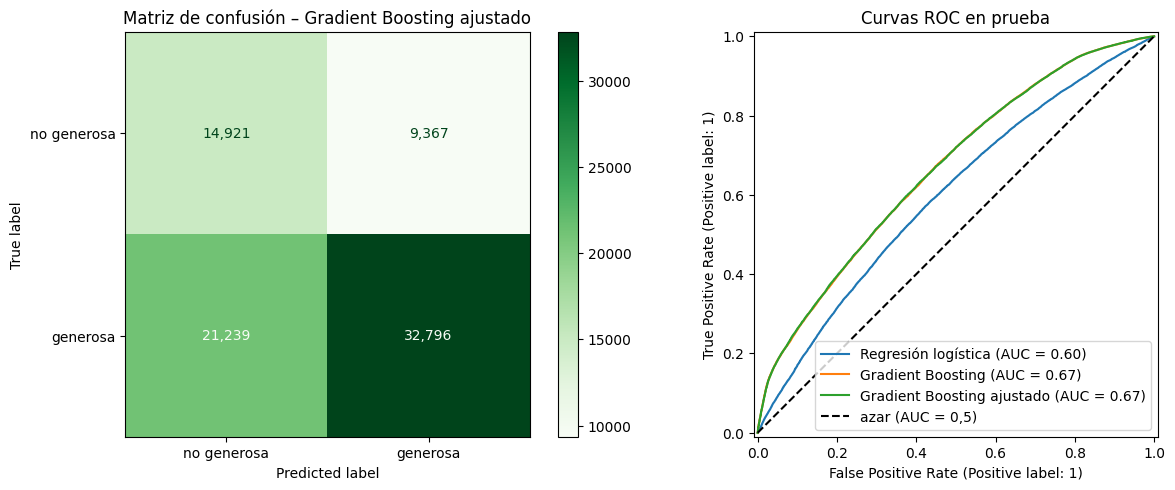

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_estimator(mejor_modelo, X_test, y_test, display_labels=["no generosa", "generosa"],
                                      cmap="Greens", values_format=",", ax=axes[0])
axes[0].set_title(f"Matriz de confusión – {NOMBRE_MEJOR}")
for nombre in ["Regresión logística", "Gradient Boosting", "Gradient Boosting ajustado"]:
    RocCurveDisplay.from_estimator(modelos[nombre], X_test, y_test, name=nombre, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", label="azar (AUC = 0,5)")
axes[1].set_title("Curvas ROC en prueba"); axes[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

In [28]:
# Comparación entrenamiento vs prueba del modelo elegido (para detectar sobreajuste)
comparacion = pd.DataFrame({
    "entrenamiento": evaluar(mejor_modelo, X_train, y_train),
    "prueba": evaluar(mejor_modelo, X_test, y_test),
})
comparacion["diferencia"] = comparacion["entrenamiento"] - comparacion["prueba"]
comparacion

,entrenamiento,prueba,diferencia
roc_auc,0.6831,0.6661,0.0170
exactitud,0.6199,0.6092,0.0107
exactitud_balanceada,0.6225,0.6106,0.0118
precision,0.7870,0.7778,0.0091
recall,0.6157,0.6069,0.0088
f1,0.6909,0.6818,0.0091
f1_macro,0.5987,0.5878,0.0110


Si la diferencia entre entrenamiento y prueba es pequeña (unas pocas centésimas), el modelo **no está sobreajustado**: lo que aprendió se generaliza a viajes que no vio.

## 13. Importancia de variables

Se usa **importancia por permutación** sobre una muestra del conjunto de prueba: se desordena una variable a la vez y se mide cuánto cae el ROC-AUC. Cuanto más cae, más depende el modelo de esa variable.

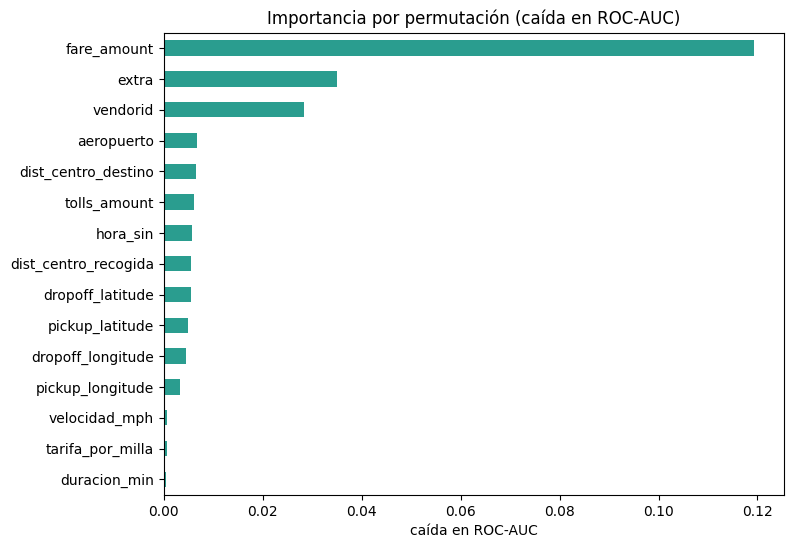

,caída en ROC-AUC
fare_amount,0.1194
extra,0.0350
vendorid,0.0283
aeropuerto,0.0067
dist_centro_destino,0.0065
tolls_amount,0.0061
hora_sin,0.0057
dist_centro_recogida,0.0056
dropoff_latitude,0.0055
pickup_latitude,0.0048


In [29]:
n_imp = min(20_000, len(X_test))
X_imp = X_test.sample(n_imp, random_state=SEMILLA)
y_imp = y_test.loc[X_imp.index]

imp = permutation_importance(mejor_modelo, X_imp, y_imp, scoring="roc_auc",
                             n_repeats=5, random_state=SEMILLA, n_jobs=-1)
importancias = pd.Series(imp.importances_mean, index=X_imp.columns).sort_values()
importancias.tail(15).plot(kind="barh", color="#2a9d8f", figsize=(8, 6))
plt.title("Importancia por permutación (caída en ROC-AUC)"); plt.xlabel("caída en ROC-AUC")
plt.show()
importancias.sort_values(ascending=False).head(10).rename("caída en ROC-AUC").to_frame()

## 14. Guardado del modelo

Se guarda el **pipeline completo** (preprocesamiento + modelo) con `joblib`. Al cargarlo, recibe directamente las variables de la sección 8 y aplica por sí mismo la imputación, la codificación y el modelo.

También se guarda `metricas.json` con las métricas, las variables que espera el modelo y las versiones de las librerías, para poder reproducir el resultado.

In [30]:
CARPETA_MODELO = "modelo"
os.makedirs(CARPETA_MODELO, exist_ok=True)
ruta_modelo = os.path.join(CARPETA_MODELO, "modelo_propina_generosa.joblib")
joblib.dump(mejor_modelo, ruta_modelo)

info = {
    "fecha": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "modelo": NOMBRE_MEJOR,
    "hiperparametros": {**{k.replace("modelo__", ""): v for k, v in busqueda.best_params_.items()},
                        "class_weight": mejor_modelo.named_steps["modelo"].class_weight}
                        if "ajustado" in NOMBRE_MEJOR else None,
    "umbral_propina": UMBRAL_PROPINA,
    "umbral_decision": 0.5,
    "variables_numericas": VARIABLES_NUMERICAS,
    "variables_categoricas": VARIABLES_CATEGORICAS,
    "filas_entrenamiento": int(len(X_train)),
    "filas_prueba": int(len(X_test)),
    "metricas_prueba": {k: round(float(v), 4) for k, v in resultados_test[NOMBRE_MEJOR].items()},
    "metricas_prueba_todos": {m: {k: round(float(v), 4) for k, v in r.items()} for m, r in resultados_test.items()},
    "versiones": {"python": platform.python_version(), "pandas": pd.__version__,
                  "scikit-learn": sklearn.__version__, "numpy": np.__version__},
}
with open(os.path.join(CARPETA_MODELO, "metricas.json"), "w", encoding="utf-8") as f:
    json.dump(info, f, ensure_ascii=False, indent=2)

print("Guardado:", ruta_modelo, f"({os.path.getsize(ruta_modelo) / 1024:,.0f} KB)")
print("Guardado:", os.path.join(CARPETA_MODELO, "metricas.json"))

Guardado: modelo/modelo_propina_generosa.joblib (397 KB)
Guardado: modelo/metricas.json


In [31]:
# Prueba: cargar el modelo guardado y predecir 5 viajes del conjunto de prueba
modelo_cargado = joblib.load(ruta_modelo)
ejemplo = X_test.head(5)
salida = ejemplo[["fare_amount", "trip_distance", "duracion_min", "vendorid", "ratecodeid"]].copy()
salida["prob_generosa"] = modelo_cargado.predict_proba(ejemplo)[:, 1].round(3)
salida["prediccion"] = modelo_cargado.predict(ejemplo)
salida["real"] = y_test.head(5).values
assert np.allclose(modelo_cargado.predict_proba(X_test)[:, 1], mejor_modelo.predict_proba(X_test)[:, 1])
salida

,fare_amount,trip_distance,duracion_min,vendorid,ratecodeid,prob_generosa,prediccion,real
350827,5.0000,0.6000,4.7333,1,1,0.8490,1,1
254600,3.0000,0.2000,1.9833,2,1,0.7650,1,1
249398,9.0000,2.0000,10.2000,1,1,0.4000,0,0
282402,13.0000,2.1500,18.2167,2,1,0.5090,1,1
247849,13.5000,2.5000,18.4000,1,1,0.4770,0,1


In [32]:
# En Colab: descargar los archivos del modelo para subirlos al repositorio (carpeta fase-1/modelo/)
try:
    from google.colab import files
    files.download(ruta_modelo)
    files.download(os.path.join(CARPETA_MODELO, "metricas.json"))
except ImportError:
    print("No está en Colab: los archivos quedaron en la carpeta", os.path.abspath(CARPETA_MODELO))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 15. Conclusiones

In [33]:
base = resultados_test["Base (clase mayoritaria)"]
mejor = resultados_test[NOMBRE_MEJOR]
print(f"Modelo elegido: {NOMBRE_MEJOR}")
print(f"ROC-AUC en prueba:             {mejor['roc_auc']:.4f}  (modelo base: {base['roc_auc']:.4f})")
print(f"Exactitud balanceada en prueba: {mejor['exactitud_balanceada']:.4f}  (modelo base: {base['exactitud_balanceada']:.4f})")
print(f"F1 macro en prueba:            {mejor['f1_macro']:.4f}  (modelo base: {base['f1_macro']:.4f})")
print("Variables más influyentes:", ", ".join(importancias.sort_values(ascending=False).head(5).index))

Modelo elegido: Gradient Boosting ajustado
ROC-AUC en prueba:             0.6661  (modelo base: 0.5000)
Exactitud balanceada en prueba: 0.6106  (modelo base: 0.5000)
F1 macro en prueba:            0.5878  (modelo base: 0.4082)
Variables más influyentes: fare_amount, extra, vendorid, aeropuerto, dist_centro_destino


- Se construyó un modelo de clasificación binaria que estima si un viaje de taxi amarillo en Nueva York, pagado con tarjeta, recibirá una propina de al menos el 20 % de la tarifa.
- Se trabajó con una muestra aleatoria reproducible del archivo de enero de 2015, filtrada a pagos con tarjeta porque las propinas en efectivo no se registran.
- La fuga de información se controló en tres niveles: se excluyeron las variables que contienen la propina (`tip_amount`, `total_amount`), se separó el conjunto de prueba antes de cualquier ajuste, y todo el preprocesamiento se hizo dentro de un `Pipeline` para que solo aprenda de los datos de entrenamiento.
- El desempeño se juzga contra el modelo base (celda anterior): la mejora real se ve en ROC-AUC, exactitud balanceada y F1 macro, que son las métricas que no se dejan engañar por la clase mayoritaria. La comparación entre entrenamiento y prueba (sección 12) permite verificar si hay sobreajuste.
- **Limitación importante:** la propina depende mucho de decisiones personales del pasajero que no están en los datos (su costumbre, su satisfacción con el servicio), así que existe un límite a lo que cualquier modelo puede predecir solo con las características del viaje. Además, las conclusiones aplican a pagos con tarjeta y a enero de 2015.
- El modelo quedó guardado en `modelo/modelo_propina_generosa.joblib` junto con sus métricas en `modelo/metricas.json`.